# Transfer Learning Image Classification Pipeline

**Dataset:** Oxford Flowers 102  
**Model:** EfficientNet-B0 (ImageNet pre-trained)  
**Task:** Classify 102 flower species using transfer learning with data augmentation.

## 1. Setup & Imports

In [ ]:
import os
import sys
from pathlib import Path

import torch
from torch import nn
import matplotlib.pyplot as plt

def _find_project_root() -> Path:
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets import create_dataloaders, FLOWERS102_CLASSES
from src.model_builder import create_efficientnet_b0, unfreeze_top_layers, get_parameter_groups
from src.engine import train, evaluate
from src.utils import plot_curves, evaluate_and_plot_confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.12.1+cpu


## 2. Data Pipeline & Augmentation

We use **Oxford Flowers 102** (8,189 images, 102 classes). The official split is:
- **Train:** 1,020 images → further split into **Train (85%)** and **Validation (15%)**
- **Test:** 6,149 images (held out for final evaluation)
**Preprocessing:** Resize to 224×224, ImageNet normalization  
**Augmentation (train only):** Random horizontal flip, rotation (±15°), color jitter

In [2]:
BATCH_SIZE = 32
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks"

train_loader, val_loader, test_loader, num_classes, class_names = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    val_ratio=0.15,
)

print(f"Classes: {num_classes}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Classes: 102
Train batches: 28 | Val batches: 5 | Test batches: 193


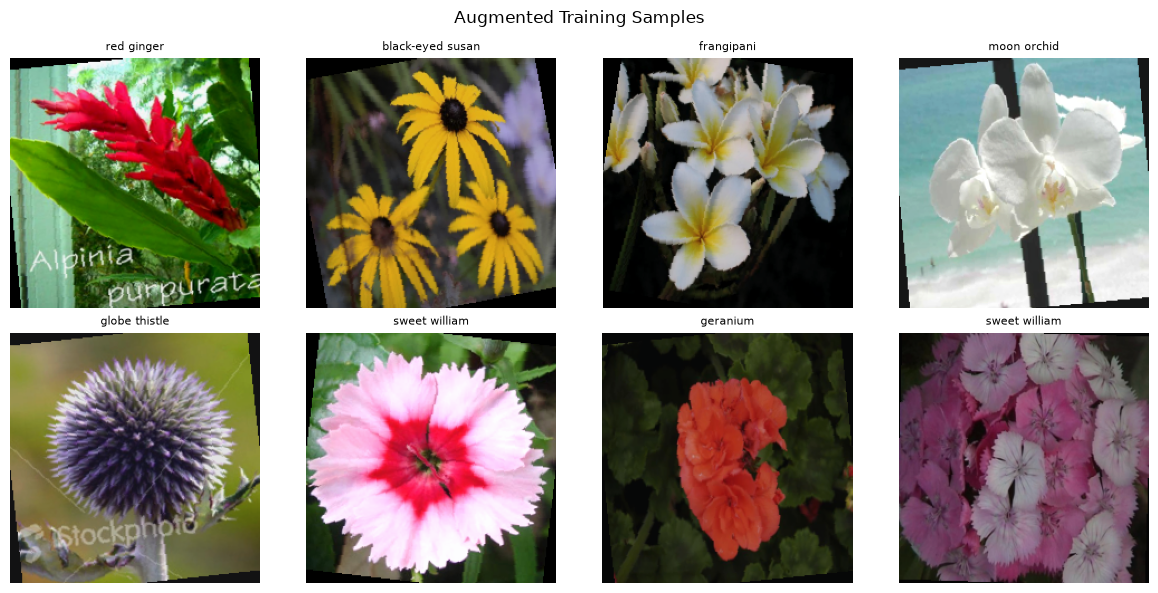

In [3]:
# Visualize a sample batch
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, images[:8], labels[:8]):
    img = img.permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # denormalize
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(class_names[label][:20], fontsize=8)
    ax.axis("off")
plt.suptitle("Augmented Training Samples")
plt.tight_layout()
plt.show()

## 3. Model Architecture (Transfer Learning)

### Why EfficientNet-B0?

| Model | Params | ImageNet Top-1 | Notes |
|-------|--------|----------------|-------|
| ResNet-50 | ~25M | ~76% | Classic baseline |
| **EfficientNet-B0** | **~5M** | **~77%** | **Best accuracy/efficiency trade-off** |
| VGG-16 | ~138M | ~72% | Heavy, slower |

EfficientNet uses **compound scaling** (depth, width, resolution) and **MBConv blocks** with squeeze-and-excitation attention. It achieves higher accuracy with fewer parameters — ideal for fine-tuning on medium-sized datasets like Flowers 102.

**Steps:**
1. Load ImageNet pre-trained weights
2. Freeze the feature extractor (`model.features`)
3. Replace the classifier head with Dropout + Linear(1280 → 102)

In [4]:
model = create_efficientnet_b0(num_classes=num_classes, freeze_features=True).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(model.classifier)

Trainable parameters: 130,662 / 4,138,210 (3.2%)
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=102, bias=True)
)


## 4. Phase 1 — Train Classifier Head

- **Loss:** CrossEntropyLoss  
- **Optimizer:** Adam (lr = 1e-3)  
- **Epochs:** 10

In [5]:
EPOCHS = 10
LR = 1e-3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LR)

results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=EPOCHS,
    device=device,
)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 4.4300 | Train Acc: 0.1064 | Val Loss: 4.0282 | Val Acc: 0.2702
Epoch 2/10 | Train Loss: 3.4011 | Train Acc: 0.5443 | Val Loss: 3.4438 | Val Acc: 0.4995
Epoch 3/10 | Train Loss: 2.5972 | Train Acc: 0.7786 | Val Loss: 2.9797 | Val Acc: 0.6048
Epoch 4/10 | Train Loss: 2.0150 | Train Acc: 0.8772 | Val Loss: 2.5518 | Val Acc: 0.6530
Epoch 5/10 | Train Loss: 1.6236 | Train Acc: 0.8713 | Val Loss: 2.2956 | Val Acc: 0.6717
Epoch 6/10 | Train Loss: 1.3319 | Train Acc: 0.9137 | Val Loss: 2.1223 | Val Acc: 0.6905
Epoch 7/10 | Train Loss: 1.1652 | Train Acc: 0.9081 | Val Loss: 1.9622 | Val Acc: 0.6905
Epoch 8/10 | Train Loss: 0.9516 | Train Acc: 0.9315 | Val Loss: 1.8967 | Val Acc: 0.6842
Epoch 9/10 | Train Loss: 0.8682 | Train Acc: 0.9412 | Val Loss: 1.7285 | Val Acc: 0.7253
Epoch 10/10 | Train Loss: 0.7813 | Train Acc: 0.9252 | Val Loss: 1.7054 | Val Acc: 0.7013


## 5. Phase 2 — Fine-Tuning (Bonus)

Unfreeze the **top 4 MBConv blocks** in the feature extractor and train with a **lower learning rate** (1e-4) to adapt high-level features without catastrophic forgetting.

In [6]:
FINE_TUNE_EPOCHS = 5
FINE_TUNE_LR = 1e-4

model = unfreeze_top_layers(model, num_layers=4)
optimizer = torch.optim.Adam(
    get_parameter_groups(model, classifier_lr=LR, backbone_lr=FINE_TUNE_LR)
)

fine_tune_results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=FINE_TUNE_EPOCHS,
    device=device,
)

for key in results:
    results[key].extend(fine_tune_results[key])

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.5099 | Train Acc: 0.9643 | Val Loss: 1.0639 | Val Acc: 0.7957
Epoch 2/5 | Train Loss: 0.2752 | Train Acc: 0.9635 | Val Loss: 0.9176 | Val Acc: 0.8082
Epoch 3/5 | Train Loss: 0.1580 | Train Acc: 0.9967 | Val Loss: 0.8895 | Val Acc: 0.8100
Epoch 4/5 | Train Loss: 0.1300 | Train Acc: 0.9955 | Val Loss: 0.8378 | Val Acc: 0.8207
Epoch 5/5 | Train Loss: 0.1461 | Train Acc: 0.9836 | Val Loss: 0.8081 | Val Acc: 0.8288


## 6. Training Curves

Saved: /home/rana/my_project/notebooks/training_curves.png


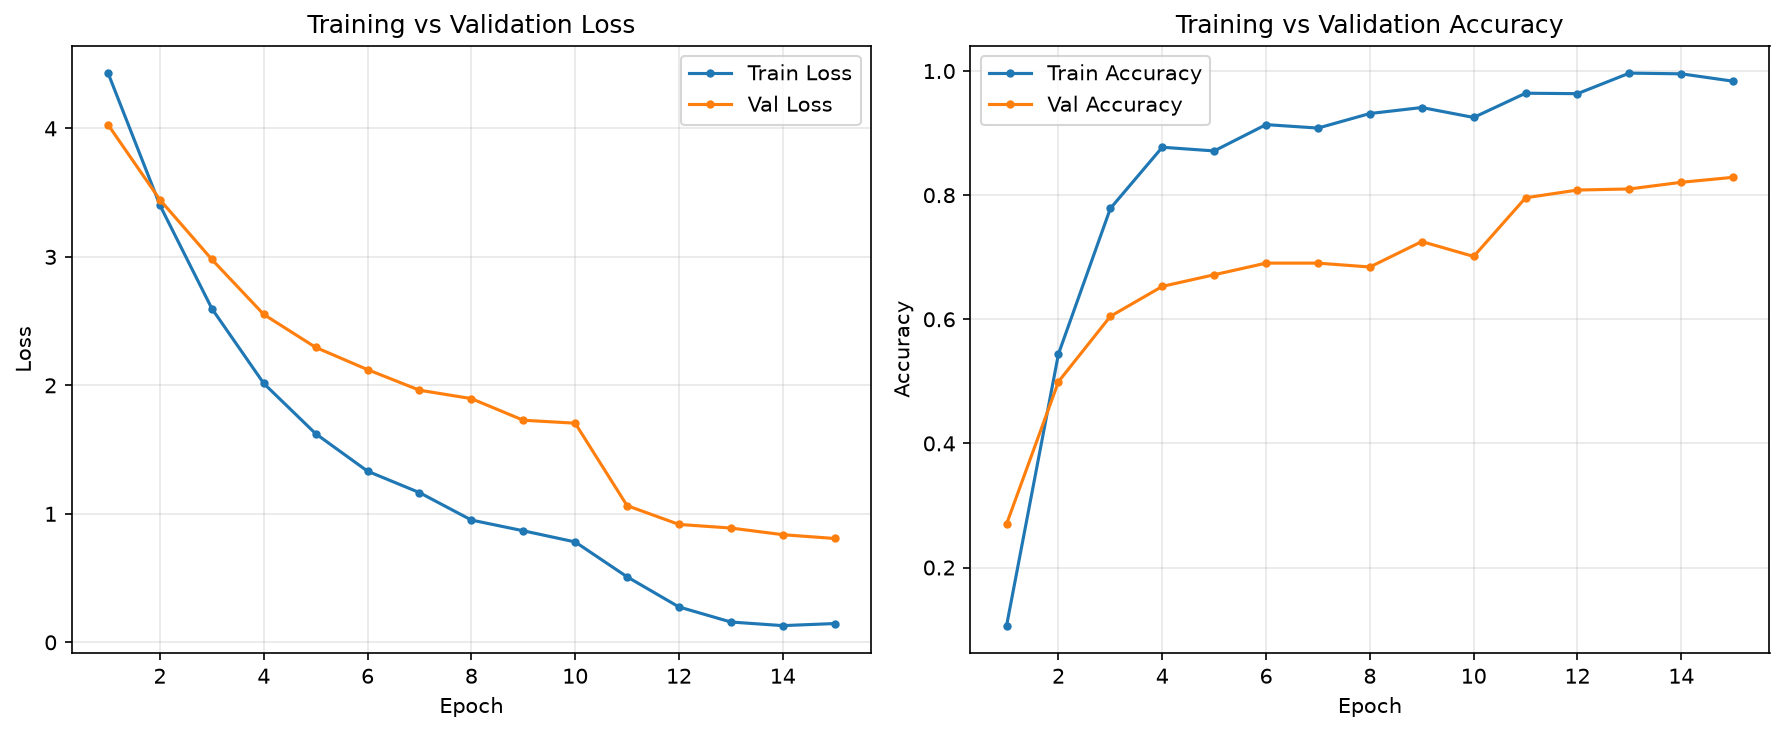

In [7]:
curves_path = plot_curves(results, save_path=OUTPUT_DIR / "training_curves.png")
print(f"Saved: {curves_path}")

from IPython.display import Image, display
display(Image(filename=str(curves_path)))

## 7. Test Set Evaluation & Confusion Matrix

Test Loss: 0.7671
Test Accuracy: 0.8170 (81.70%)
Saved: /home/rana/my_project/notebooks/confusion_matrix.png
                           precision    recall  f1-score   support

            pink primrose       0.35      0.95      0.51        20
hard-leaved pocket orchid       0.97      0.95      0.96        40
         canterbury bells       0.25      0.15      0.19        20
                sweet pea       0.47      0.50      0.49        36
         english marigold       0.90      0.82      0.86        45
               tiger lily       0.92      0.92      0.92        25
              moon orchid       0.67      1.00      0.80        20
         bird of paradise       0.93      1.00      0.96        65
                monkshood       0.62      0.62      0.62        26
            globe thistle       0.76      1.00      0.86        25
               snapdragon       0.52      0.69      0.59        67
              colt's foot       0.95      0.90      0.92        67
              king 

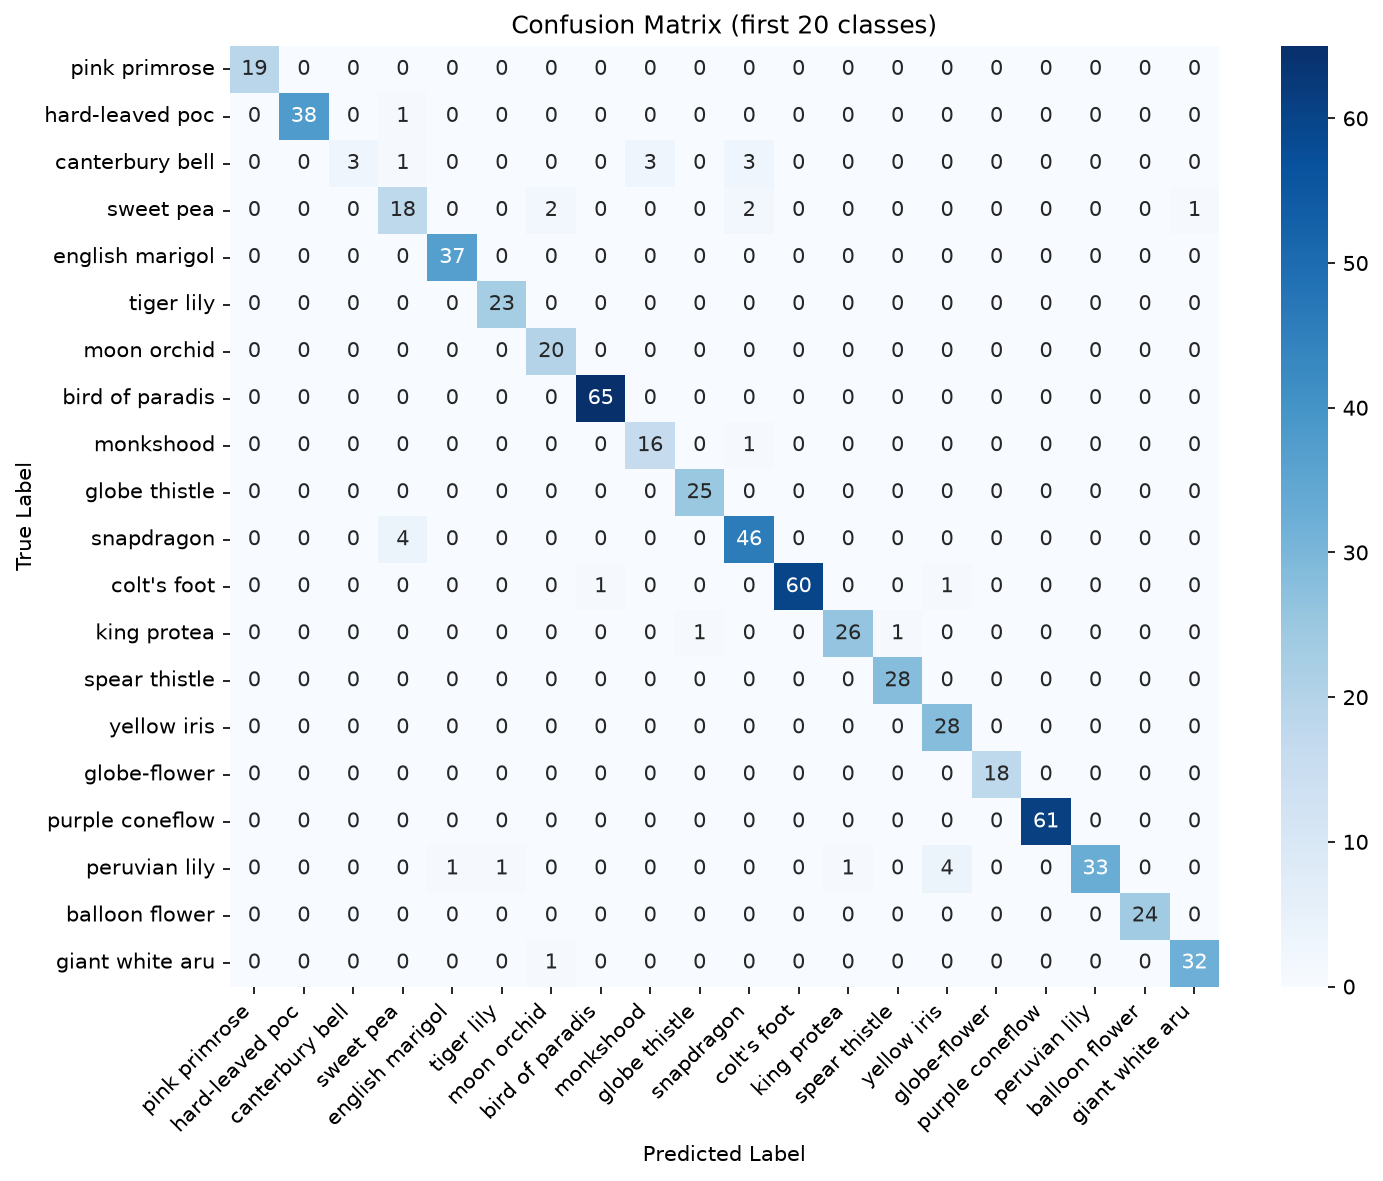

In [8]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

cm_path, report, _ = evaluate_and_plot_confusion_matrix(
    model=model,
    dataloader=test_loader,
    class_names=class_names,
    device=device,
    save_path=OUTPUT_DIR / "confusion_matrix.png",
)
print(f"Saved: {cm_path}")
print(report)

display(Image(filename=str(cm_path)))

In [9]:
checkpoint_path = OUTPUT_DIR / "efficientnet_b0_flowers102.pt"
torch.save({"model_state_dict": model.state_dict(), "num_classes": num_classes}, checkpoint_path)
print(f"Model saved to {checkpoint_path}")

Model saved to /home/rana/my_project/notebooks/efficientnet_b0_flowers102.pt
